In [79]:
# -------------------------------
# STEP 1: Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [80]:
# -------------------------------
# STEP 2: Load Data

df = pd.read_csv("loan_default.csv")  # Replace with your actual file


In [81]:
# -------------------------------
# STEP 3: Feature Engineering

df['income_to_expense_ratio'] = df['annual_income'] / (df['monthly_expenses'] * 12 + 1)
df['dependents'] = df['old_dependents'] + df['young_dependents']
df.drop(columns=['old_dependents', 'young_dependents'], inplace=True)

# Drop weak features (if present)
weak_features = ['sex', 'home_ownership', 'type_of_house', 'water_availabity', 'Id']
df = df.drop(columns=[col for col in weak_features if col in df.columns])


In [85]:
# -------------------------------
# STEP 4: Preprocessing

X = df.drop(columns=['loan_amount'])
y = df['loan_amount']

# Split columns by type
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ColumnTransformer for encoding + scaling
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(transformers=[
    ('num', make_pipeline(SimpleImputer(strategy='median'), MinMaxScaler()), num_cols),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat_cols)
])


In [86]:
# -------------------------------
# STEP 5: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [87]:
# -------------------------------
# STEP 6: Train Random Forest Model

# Create pipeline
rf_pipeline = make_pipeline(preprocessor, RandomForestRegressor(n_estimators=100, random_state=42))

# Train
rf_pipeline.fit(X_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['age', 'annual_income',
                                                   'monthly_expenses',
                                                   'occupants_count',
                                                   'house_area',
                                                   'sanitary_availability',
                                                   'loan_tenure',
                                                   'loan_installments',
                                                   'income_to_expense_ratio',
                                                   'dependents']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['city', 'social_class',
                                                   'primary_business',
                                                   'secondary_business',
                                                   'loan_purpose'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [88]:
# -------------------------------
# STEP 7: Evaluate the Model

y_pred = rf_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("✅ Random Forest Evaluation")
print(f"MAE: ₹{mae:.2f}")
print(f"MSE: ₹{mse:.2f}")
print(f"R² Score: {r2:.4f}")


✅ Random Forest Evaluation
MAE: ₹1312.50
MSE: ₹91647516.88
R² Score: 0.6005


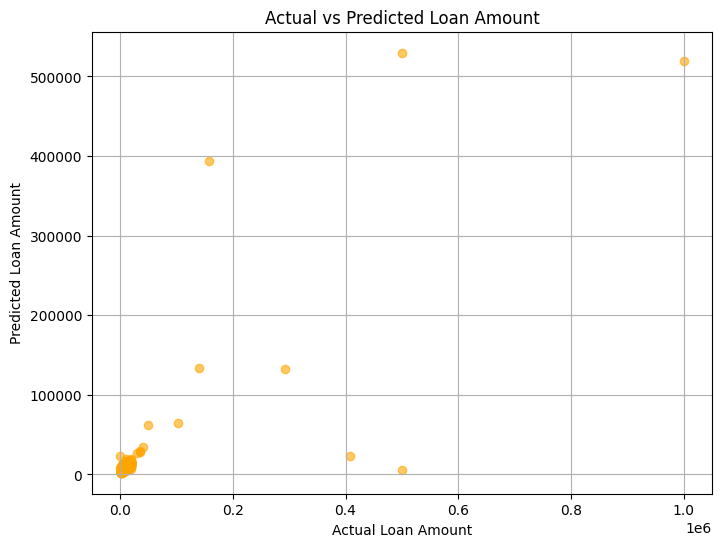

In [89]:
# -------------------------------
# STEP 8: Visualize Predictions

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='orange')
plt.xlabel("Actual Loan Amount")
plt.ylabel("Predicted Loan Amount")
plt.title("Actual vs Predicted Loan Amount")
plt.grid(True)
plt.show()


In [90]:
# -------------------------------
# STEP 9: Save Model

joblib.dump(rf_pipeline, "loan_amount_rf_model.pkl")
print("✅ Model saved as 'loan_amount_rf_model.pkl'")



✅ Model saved as 'loan_amount_rf_model.pkl'
